<a href="https://colab.research.google.com/github/Krishnauprit18/Hybrid-DDOS-Detection-System/blob/master/DDOS_RP_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support


In [ ]:
# ---------------------------------------
# Load Data
# ---------------------------------------
file_path = "/content/sample_data/DNS_Dataset.csv"  # Update file path if required
data = pd.read_csv(file_path)

In [ ]:
# ---------------------------------------
# Basic Statistical Summary
# ---------------------------------------
data.describe()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,6703.000000,6.703000e+03,6703.000000,6703.000000,6.703000e+03,6.703000e+03,6703.000000,6703.000000,6703.000000,6703.000000,...,6703.000000,6.703000e+03,6.703000e+03,6.703000e+03,6.703000e+03,6.703000e+03,6.703000e+03,6.703000e+03,6.703000e+03,6.703000e+03
mean,13.825302,4.408433e+06,7.896464,4.509324,6.072777e+03,4.959965e+03,619.654036,556.014919,568.574474,18.800081,...,5.030434,-2.843068e+07,3.643757e+04,7.590772e+03,4.712779e+04,3.157412e+04,1.575373e+06,7.806843e+04,1.640308e+06,1.508151e+06
std,5.085899,1.988634e+07,90.663250,80.574949,2.267235e+05,1.880782e+05,800.769721,630.355276,623.797414,91.294982,...,81.627561,1.717053e+08,3.799835e+05,1.226665e+05,4.406432e+05,3.514015e+05,8.449426e+06,1.248229e+06,8.776632e+06,8.240104e+06
min,0.000000,1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.408238e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.000000,2.000000e+00,2.000000,0.000000,7.400000e+01,0.000000e+00,37.000000,0.000000,31.000000,0.000000,...,1.000000,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,17.000000,4.800000e+01,2.000000,0.000000,7.620000e+02,0.000000e+00,362.000000,180.000000,238.608690,0.000000,...,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,17.000000,2.086350e+04,2.000000,2.000000,2.896000e+03,7.200000e+01,1434.000000,1424.000000,1424.000000,0.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,17.000000,1.199810e+08,5063.000000,4602.000000,1.526642e+07,1.099376e+07,32120.000000,2020.000000,3015.290500,2221.556200,...,5043.000000,1.480000e+03,9.218128e+06,7.531216e+06,1.280159e+07,6.342870e+06,8.421053e+07,6.600292e+07,1.037700e+08,8.421053e+07


In [ ]:
data.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS


In [ ]:
data.tail()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
6698,0,19029778,12,0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0,6.0,0.0,6.0,6.0,9514880.0,8402.55,9520821.0,9508938.0,Benign
6699,6,171239,1,1,0.0,0.0,0.0,0.0,0.0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,Benign
6700,6,221,1,2,0.0,0.0,0.0,0.0,0.0,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,Benign
6701,6,62253,4,2,92.0,92.0,46.0,0.0,23.0,26.558113,...,20,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,Benign
6702,0,19059205,9,0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0,5.0,0.0,5.0,5.0,9529594.0,337784.90,9768444.0,9290744.0,Benign


<Figure size 1200x1000 with 0 Axes>

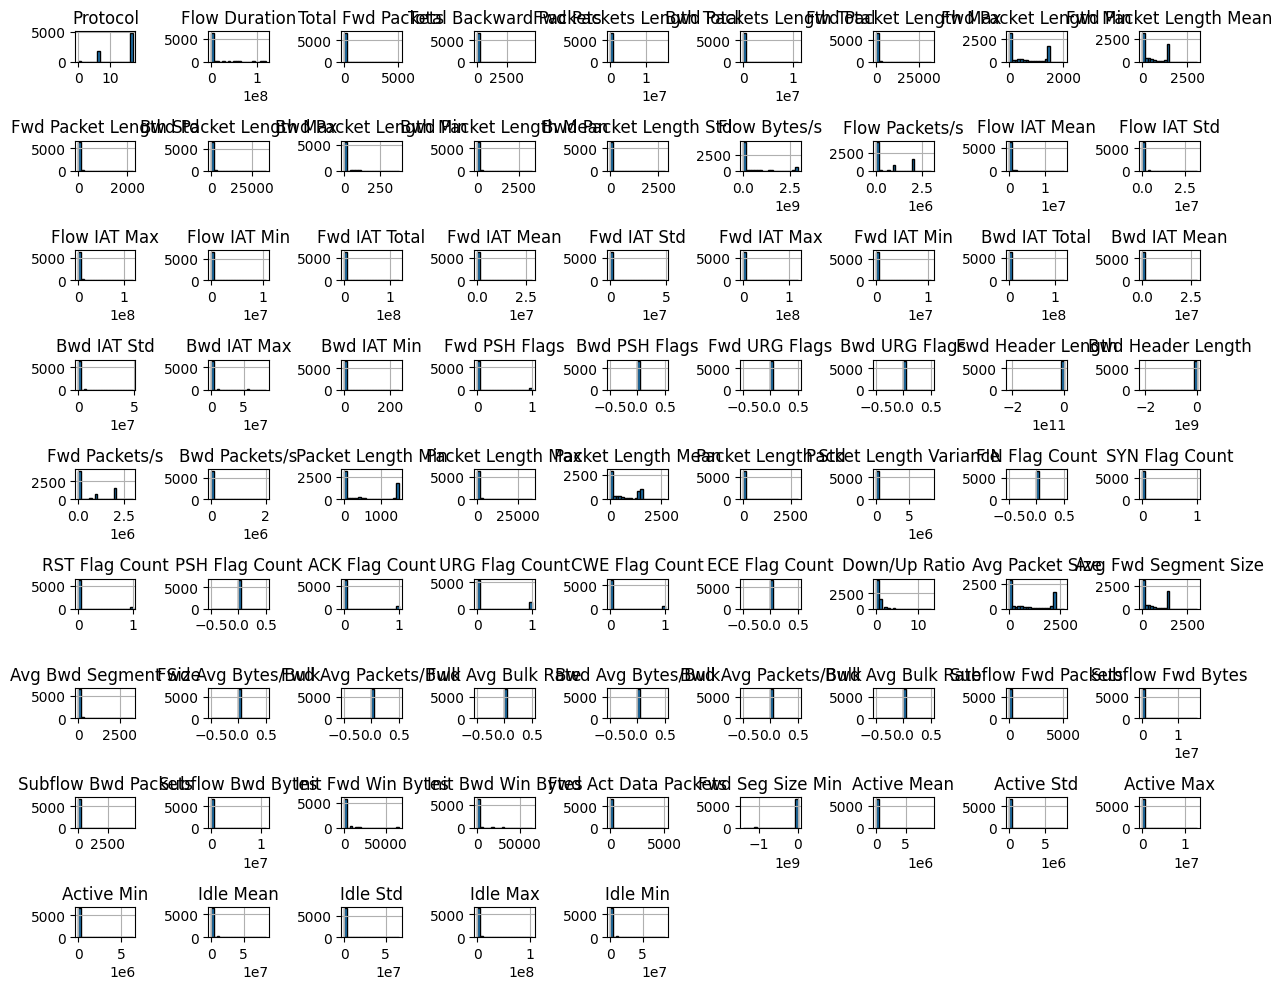

In [ ]:
# Distribution Plots (Histogram)

plt.figure(figsize=(12, 10))

data.hist(bins=20, edgecolor='black', figsize=(12, 10))

plt.tight_layout()

plt.show()


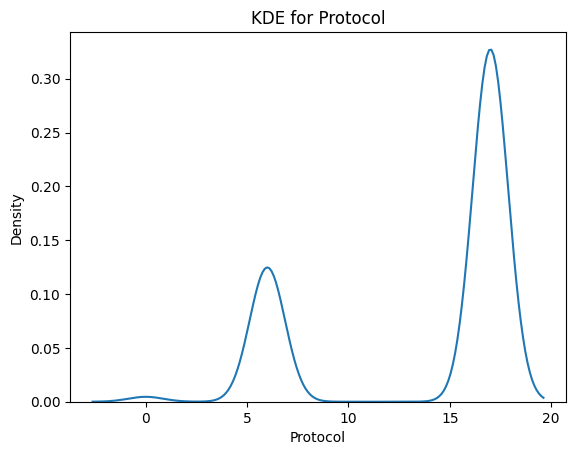

In [ ]:
# Kernel Density Estimate plot for a single numeric column (replace 'feature1' with a numeric column in the dataset)

numeric_columns = data.select_dtypes(include=np.number).columns

if len(numeric_columns) > 0:

    sns.kdeplot(data=data, x=numeric_columns[0])

    plt.title(f'KDE for {numeric_columns[0]}')

    plt.show()


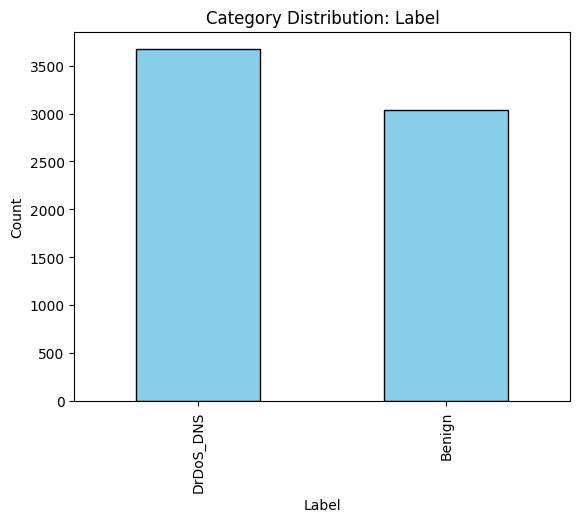

In [ ]:
# Bar Plots

categorical_columns = data.select_dtypes(include=['object', 'category']).columns

if len(categorical_columns) > 0:

    data[categorical_columns[0]].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')

    plt.xlabel(categorical_columns[0])

    plt.ylabel('Count')

    plt.title(f'Category Distribution: {categorical_columns[0]}')

    plt.show()


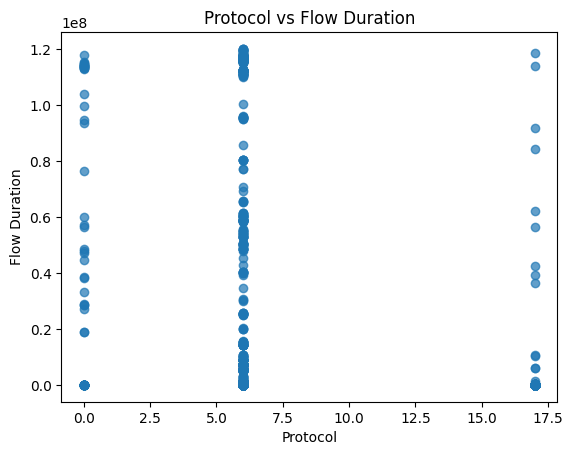

In [ ]:
# Scatter Plot

if len(numeric_columns) > 1:

    plt.scatter(data[numeric_columns[0]], data[numeric_columns[1]], alpha=0.7)

    plt.xlabel(numeric_columns[0])

    plt.ylabel(numeric_columns[1])

    plt.title(f'{numeric_columns[0]} vs {numeric_columns[1]}')

    plt.show()


In [ ]:
# ---------------------------------------
# Data Preprocessing
# ---------------------------------------
# Imputation for missing values
imputer = SimpleImputer(strategy="mean")
data_imputed = pd.DataFrame(imputer.fit_transform(data.select_dtypes(include=np.number)), columns=data.select_dtypes(include=np.number).columns)


In [ ]:
# Encoding categorical variables
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le


In [ ]:
# Standardize numeric columns
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(data_imputed), columns=data_imputed.columns)

# Merge processed numeric and categorical data
final_data = pd.concat([scaled_data, data.select_dtypes(include='int64')], axis=1)


In [ ]:
# Train-Test Split
X = final_data.drop('Label', axis=1, errors='ignore')  # Replace 'target_column' with your target
y = final_data['Label']  # Replace 'target_column' with your target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.9776286353467561
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       585
           1       0.98      0.98      0.98       756

    accuracy                           0.98      1341
   macro avg       0.98      0.98      0.98      1341
weighted avg       0.98      0.98      0.98      1341



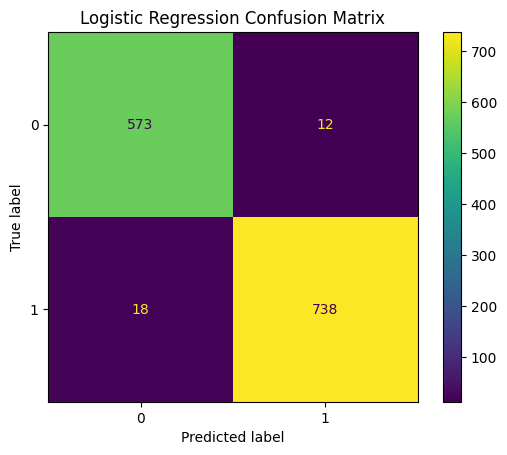

In [ ]:
# ---------------------------------------
# Logistic Regression
# ---------------------------------------
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print(classification_report(y_test, y_pred_log_reg))

# Plot Logistic Regression Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
ConfusionMatrixDisplay(confusion_matrix=cm_log_reg).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Decision Tree Accuracy: 0.9970171513795675
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       585
           1       1.00      1.00      1.00       756

    accuracy                           1.00      1341
   macro avg       1.00      1.00      1.00      1341
weighted avg       1.00      1.00      1.00      1341



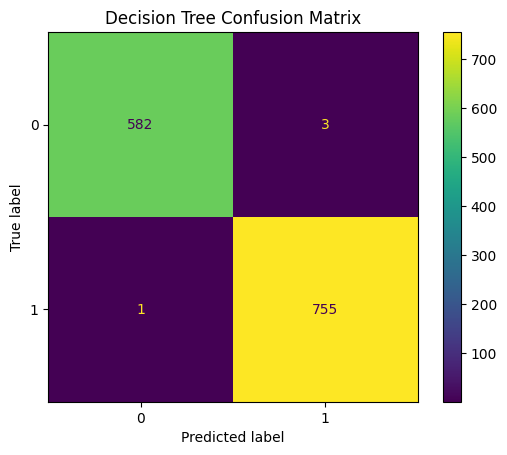

In [ ]:
# ---------------------------------------
# Decision Tree Classifier
# ---------------------------------------
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_tree = decision_tree.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

# Plot Decision Tree Confusion Matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
ConfusionMatrixDisplay(confusion_matrix=cm_tree).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

Random Forest Accuracy: 0.9992542878448919
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       585
           1       1.00      1.00      1.00       756

    accuracy                           1.00      1341
   macro avg       1.00      1.00      1.00      1341
weighted avg       1.00      1.00      1.00      1341



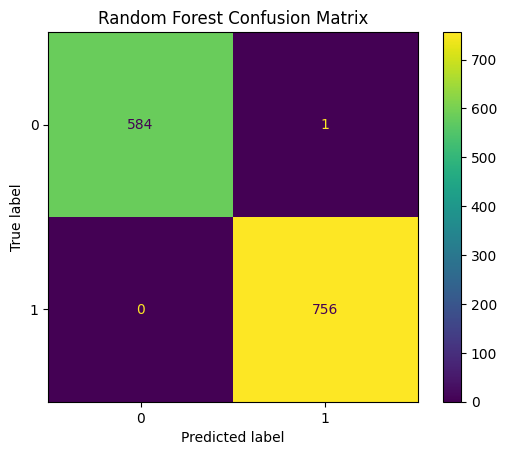

In [ ]:
# ---------------------------------------
# Random Forest Classifier
# ---------------------------------------
random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)
y_pred_forest = random_forest.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_forest))
print(classification_report(y_test, y_pred_forest))

# Plot Random Forest Confusion Matrix
cm_forest = confusion_matrix(y_test, y_pred_forest)
ConfusionMatrixDisplay(confusion_matrix=cm_forest).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

SVM Accuracy: 0.5637583892617449
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       585
           1       0.56      1.00      0.72       756

    accuracy                           0.56      1341
   macro avg       0.28      0.50      0.36      1341
weighted avg       0.32      0.56      0.41      1341



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


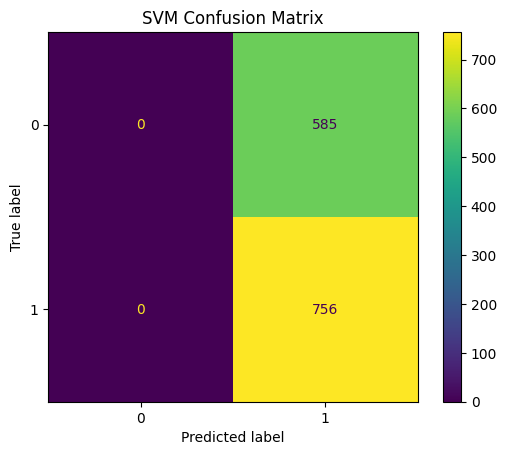

In [ ]:
# ---------------------------------------
# Support Vector Machine (SVM)
# ---------------------------------------
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

# Plot SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(confusion_matrix=cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
# ---------------------------------------
# Model Evaluation Summary
# ---------------------------------------
models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM']
predictions = [y_pred_log_reg, y_pred_tree, y_pred_forest, y_pred_svm]
accuracies = []
precisions = []
recalls = []
f1_scores = []

for model, y_pred in zip(models, predictions):
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    print(f"{model} Results:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}\n")

Logistic Regression Results:
Accuracy: 0.98
Precision: 0.98
Recall: 0.98
F1-Score: 0.98

Decision Tree Results:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00

Random Forest Results:
Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1-Score: 1.00

SVM Results:
Accuracy: 0.56
Precision: 0.32
Recall: 0.56
F1-Score: 0.41



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


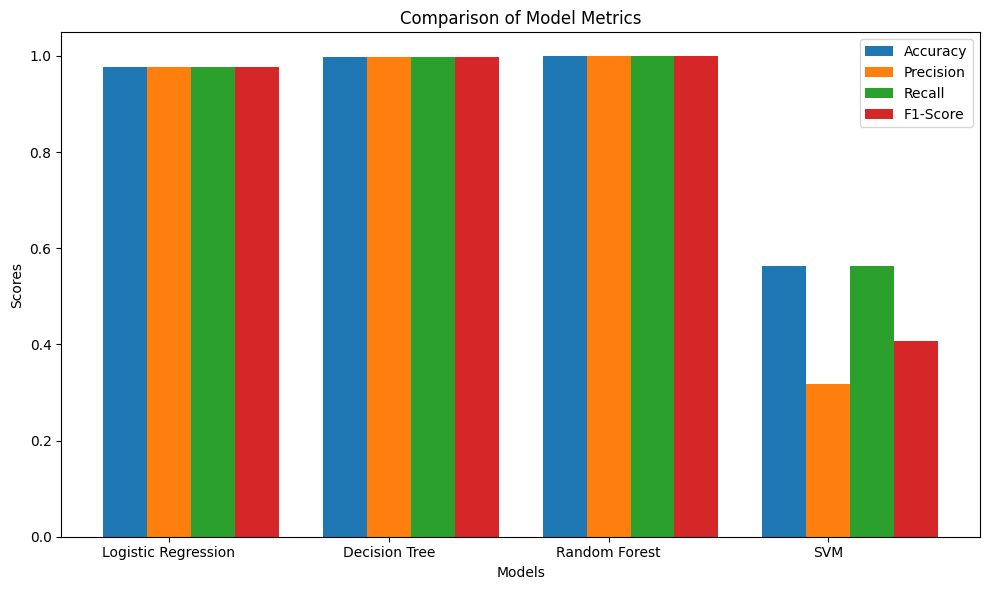

In [ ]:
# ---------------------------------------
# Comparison Plot
# ---------------------------------------
x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, accuracies, width, label='Accuracy')
ax.bar(x, precisions, width, label='Precision')
ax.bar(x + width, recalls, width, label='Recall')
ax.bar(x + 2 * width, f1_scores, width, label='F1-Score')

ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Comparison of Model Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Deep Learning:-

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, LSTM, SimpleRNN, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
# Imputation for missing values
imputer = SimpleImputer(strategy="mean")
data_imputed = pd.DataFrame(imputer.fit_transform(data.select_dtypes(include=np.number)), columns=data.select_dtypes(include=np.number).columns)

# Encoding categorical variables
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

In [ ]:
# Standardizing numeric columns
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(data_imputed), columns=data_imputed.columns)

# Merging processed numeric and categorical data
final_data = pd.concat([scaled_data, data.select_dtypes(include='int64')], axis=1)

In [ ]:
# Train-Test Split
X = final_data.drop('Label', axis=1, errors='ignore')  # Replace 'Label' with the target column name
y = final_data['Label']  # Replace 'Label' with the target column name

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ensure target is one-hot encoded and remove extra dimensions
y_train_encoded = to_categorical(y_train).reshape(-1, len(np.unique(y)))
y_test_encoded = to_categorical(y_test).reshape(-1, len(np.unique(y)))

input_shape = (X_train.shape[1],)
image_shape = (X_train.shape[1], 1, 1)
sequence_shape = (X_train.shape[1], 1)

X_train_cnn = X_train.values.reshape(-1, *image_shape)
X_test_cnn = X_test.values.reshape(-1, *image_shape)
X_train_rnn = X_train.values.reshape(-1, *sequence_shape)
X_test_rnn = X_test.values.reshape(-1, *sequence_shape)

In [ ]:
# Function to Plot Training History
def plot_training_history(history, title):
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['loss'], label='Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid()
    plt.show()

# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(title)
    plt.show()

In [ ]:
# Function to Evaluate Model
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test.argmax(axis=1), y_pred.argmax(axis=1))
    print(f"{title} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))
    plot_confusion_matrix(y_test, y_pred, f"{title} Confusion Matrix")
    return accuracy

# Store Model Accuracies
model_accuracies = {}

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4721 - loss: 2.2030
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6968 - loss: 2.4803
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4751 - loss: 5.2719
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4136 - loss: 16.9226
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4107 - loss: 20.4724
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4998 - loss: 14.1009
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5218 - loss: 17.2064
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4764 - loss: 38.1387
Epoch 9/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5101 - loss: 33.0172
Epoch 10/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5004 - loss: 37.6719
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Sequential Neural Network Classification Report:
              precision    recall  f1-score

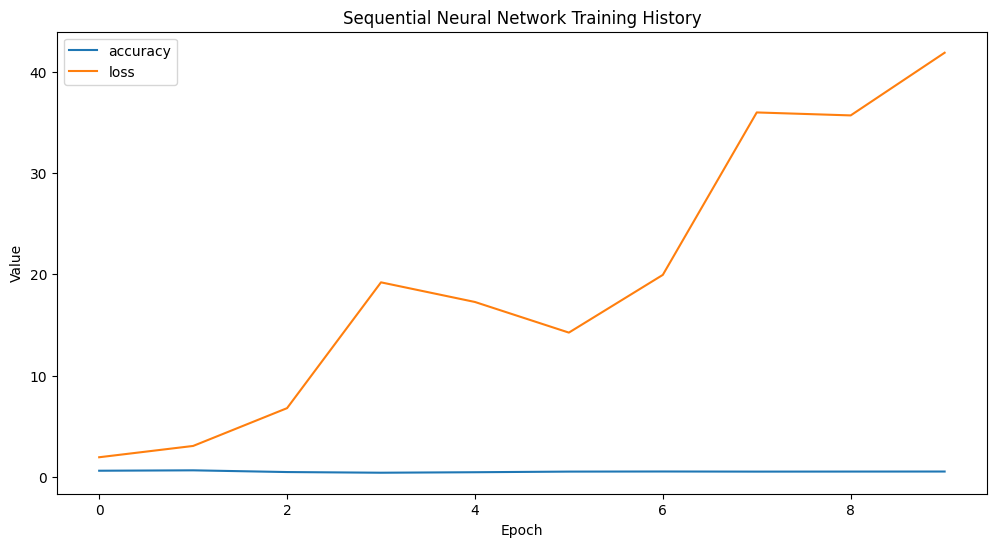

In [ ]:
# ---------------------------------------
# Sequential Neural Network
# ---------------------------------------
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import numpy as np

# Recheck scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Rebuild the Sequential Neural Network
seq_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dense(y_train_encoded.shape[1], activation='softmax')
])

# Use a smaller learning rate
optimizer = Adam(learning_rate=0.001)

seq_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_seq = seq_model.fit(X_train_scaled, y_train_encoded, epochs=10, batch_size=32, verbose=1)

# Evaluate the model
def evaluate_model(model, X_test, y_test, model_name):
    # Get predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # Print classification report
    report = classification_report(y_true_classes, y_pred_classes, zero_division=0)
    print(f"{model_name} Classification Report:\n{report}")

    # Calculate accuracy
    accuracy = np.mean(y_pred_classes == y_true_classes)
    print(f"{model_name} Accuracy: {accuracy:.2f}")

    return accuracy

model_accuracies = {}
model_accuracies['Sequential Neural Network'] = evaluate_model(
    seq_model, X_test_scaled, y_test_encoded, 'Sequential Neural Network'
)

# Plot training history
def plot_training_history(history, model_name):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['loss'], label='loss')
    plt.title(f'{model_name} Training History')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

plot_training_history(history_seq, 'Sequential Neural Network')



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam


In [ ]:
# ---------------------------------------
# FeedForward Neural Network
# ---------------------------------------
# Build the FeedForward Neural Network
ff_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dense(y_train_encoded.shape[1], activation='softmax')
])

# Use a smaller learning rate
optimizer = Adam(learning_rate=0.001)

In [ ]:
# Compile the model
ff_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_ff = ff_model.fit(X_train_scaled, y_train_encoded, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5453 - loss: 2.8536
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5160 - loss: 8.0892
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4663 - loss: 24.9584
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4592 - loss: 35.1678
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4636 - loss: 48.5168
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4728 - loss: 58.9177
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4736 - loss: 88.6565
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4624 - loss: 116.9713
Epoch 9/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4739 - loss: 136.3750
Epoch 10/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4538 - loss: 144.6924


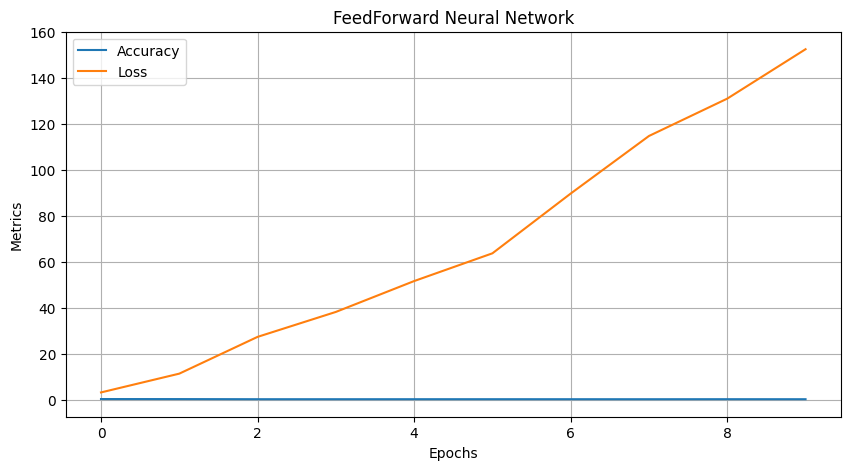

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
FeedForward Neural Network Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       756
           1       1.00      0.99      1.00       585
           3       0.00      0.00      0.00         0

    accuracy                           0.98      1341
   macro avg       0.67      0.65      0.66      1341
weighted avg       1.00      0.98      0.99      1341



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


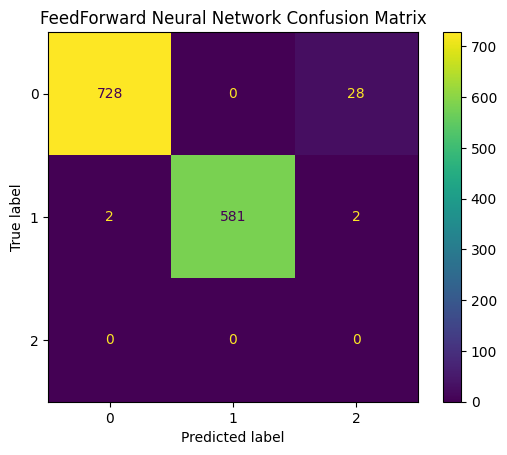

In [ ]:
# Function to Plot Training History
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['loss'], label='Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid()
    plt.show()

# Plot training history
plot_training_history(history_ff, 'FeedForward Neural Network')

# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(title)
    plt.show()

# Function to Evaluate Model
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test.argmax(axis=1), y_pred.argmax(axis=1))
    print(f"{title} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))
    plot_confusion_matrix(y_test, y_pred, f"{title} Confusion Matrix")
    return accuracy

# Evaluate the model
ff_accuracy = evaluate_model(ff_model, X_test_scaled, y_test_encoded, 'FeedForward Neural Network')

Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5429 - loss: 17.6685
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4612 - loss: 641.4249
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3700 - loss: 4691.9253
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3531 - loss: 14024.6309
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3073 - loss: 29115.4844
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2628 - loss: 58741.4727
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2777 - loss: 82585.8281
Epoch 8/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2896 - loss: 151334.3125
Epoch 9/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2737 - loss: 234765.2656
Epoch 10/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2548 - loss: 291427.2188
Epoch 11/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2684 - loss: 402247.3438
Epoch 12/

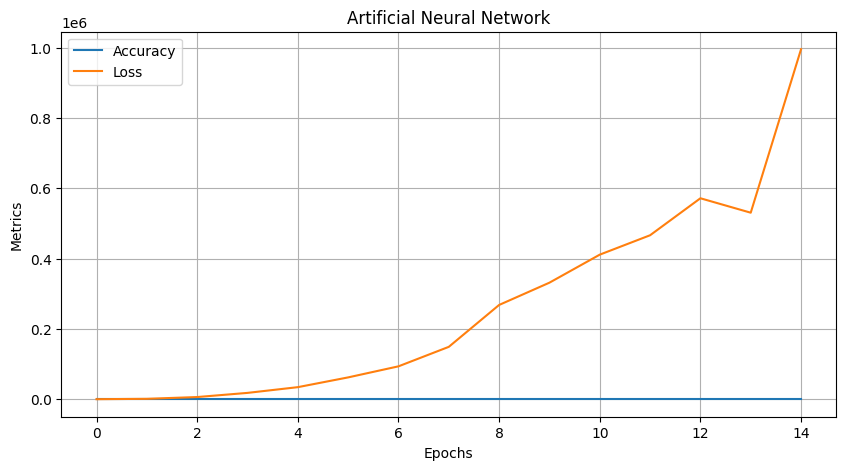

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Artificial Neural Network Accuracy: 0.00
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     756.0
           1       0.00      0.00      0.00     585.0
           3       0.00      0.00      0.00       0.0

    accuracy                           0.00    1341.0
   macro avg       0.00      0.00      0.00    1341.0
weighted avg       0.00      0.00      0.00    1341.0



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

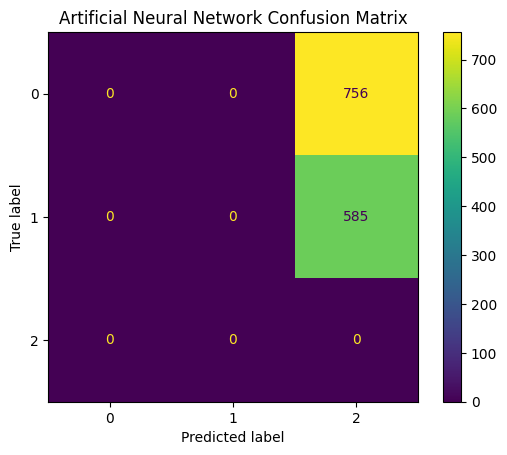

In [ ]:
# ---------------------------------------
# Artificial Neural Network
# ---------------------------------------
# Build the Artificial Neural Network
ann_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(256, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dense(y_train_encoded.shape[1], activation='softmax')
])

# Use a smaller learning rate
optimizer = Adam(learning_rate=0.001)

# Compile the model
ann_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_ann = ann_model.fit(X_train_scaled, y_train_encoded, epochs=15, batch_size=32, verbose=1)

# Function to Plot Training History
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['loss'], label='Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid()
    plt.show()

# Plot training history
plot_training_history(history_ann, 'Artificial Neural Network')

# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(title)
    plt.show()

# Function to Evaluate Model
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test.argmax(axis=1), y_pred.argmax(axis=1))
    print(f"{title} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))
    plot_confusion_matrix(y_test, y_pred, f"{title} Confusion Matrix")
    return accuracy

# Evaluate the model
ann_accuracy = evaluate_model(ann_model, X_test_scaled, y_test_encoded, 'Artificial Neural Network')


Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.3502 - loss: 1422.4259
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2687 - loss: 184142.3281
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2256 - loss: 2503458.0000
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2428 - loss: 13849092.0000
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2482 - loss: 42508648.0000
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2706 - loss: 157849344.0000
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2434 - loss: 288863744.0000
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2634 - loss: 406265408.0000
Epoch 9/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2927 - loss: 654381184.0000
Epoch 10/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2370 - loss: 858028352.0000
Epoch 11/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.26

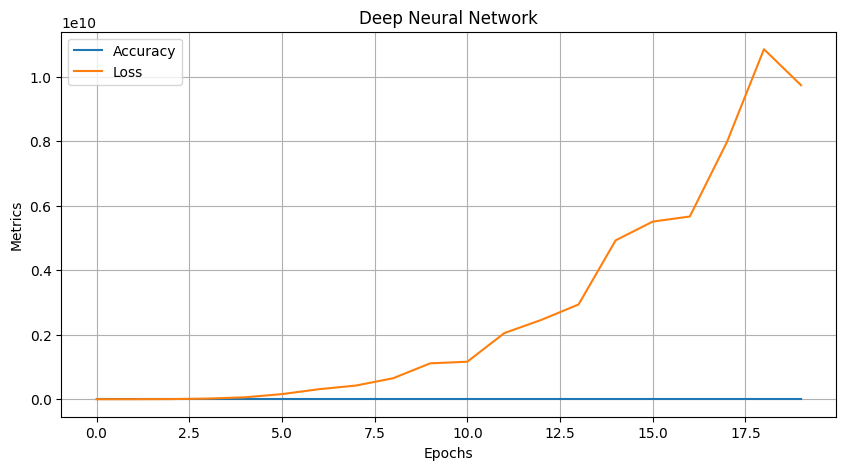

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Deep Neural Network Accuracy: 0.00
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     756.0
           1       0.00      0.00      0.00     585.0
           3       0.00      0.00      0.00       0.0

    accuracy                           0.00    1341.0
   macro avg       0.00      0.00      0.00    1341.0
weighted avg       0.00      0.00      0.00    1341.0



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

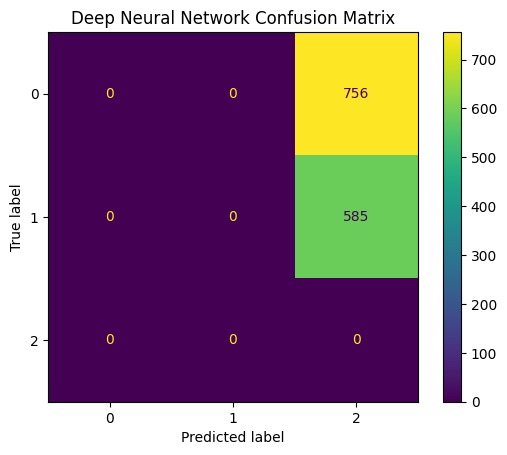

In [ ]:
# ---------------------------------------
# Deep Neural Network
# ---------------------------------------
# Build the Deep Neural Network
dnn_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(512, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dense(y_train_encoded.shape[1], activation='softmax')
])

# Use a smaller learning rate
optimizer = Adam(learning_rate=0.001)

# Compile the model
dnn_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_dnn = dnn_model.fit(X_train_scaled, y_train_encoded, epochs=20, batch_size=32, verbose=1)

# Function to Plot Training History
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['loss'], label='Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid()
    plt.show()

# Plot training history
plot_training_history(history_dnn, 'Deep Neural Network')

# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(title)
    plt.show()

# Function to Evaluate Model
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test.argmax(axis=1), y_pred.argmax(axis=1))
    print(f"{title} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))
    plot_confusion_matrix(y_test, y_pred, f"{title} Confusion Matrix")
    return accuracy

# Evaluate the model
dnn_accuracy = evaluate_model(dnn_model, X_test_scaled, y_test_encoded, 'Deep Neural Network')


Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.2958 - loss: 409.2573
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2900 - loss: 33408.2383
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2497 - loss: 252264.0000
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2596 - loss: 737412.1250
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2650 - loss: 1502134.5000
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2519 - loss: 2315948.0000
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2471 - loss: 2985414.2500
Epoch 8/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2588 - loss: 3472385.0000
Epoch 9/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2556 - loss: 3263628.2500
Epoch 10/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2582 - loss: 2892150.2500
Epoch 11/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2513 - loss: 188885

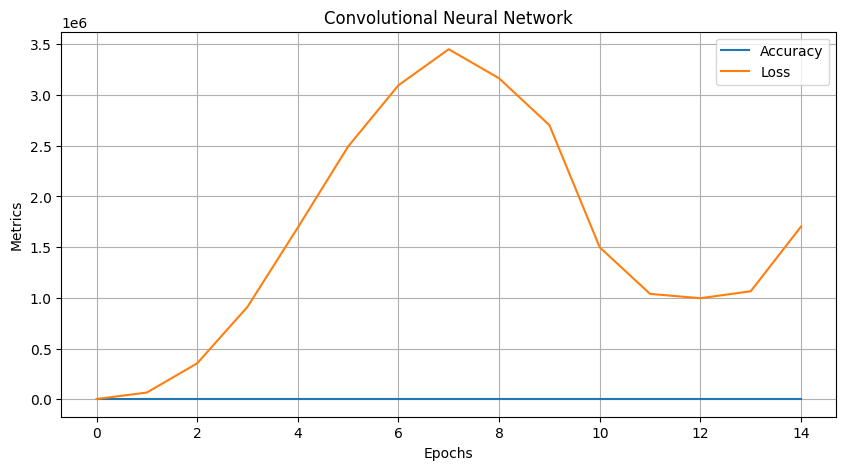

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Convolutional Neural Network Accuracy: 0.00
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     756.0
           1       0.00      0.00      0.00     585.0
           3       0.00      0.00      0.00       0.0

    accuracy                           0.00    1341.0
   macro avg       0.00      0.00      0.00    1341.0
weighted avg       0.00      0.00      0.00    1341.0



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

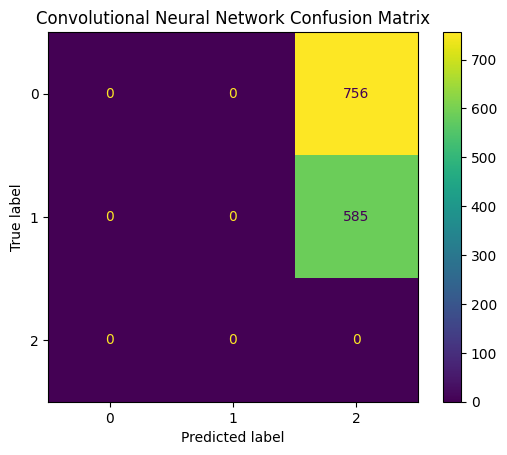

In [ ]:
# ---------------------------------------
# Convolutional Neural Network
# ---------------------------------------
# Reshape data for CNN
X_train_cnn = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1, 1)
X_test_cnn = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1, 1)

# Ensure the input dimensions for CNN pooling layers are valid
if X_train_cnn.shape[1] < 3:
    raise ValueError("Input width is too small for pooling operations. Increase input dimensions or reduce pooling kernel size.")

# Build the Convolutional Neural Network
cnn_model = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 1)),  # Adjust pooling to handle narrow dimensions
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 1)),  # Adjust pooling to handle narrow dimensions
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train_encoded.shape[1], activation='softmax')
])

# Use a smaller learning rate
optimizer = Adam(learning_rate=0.001)

# Compile the model
cnn_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_cnn = cnn_model.fit(X_train_cnn, y_train_encoded, epochs=15, batch_size=32, verbose=1)

# Function to Plot Training History
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['loss'], label='Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid()
    plt.show()

# Plot training history
plot_training_history(history_cnn, 'Convolutional Neural Network')

# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(title)
    plt.show()

# Function to Evaluate Model
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test.argmax(axis=1), y_pred.argmax(axis=1))
    print(f"{title} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))
    plot_confusion_matrix(y_test, y_pred, f"{title} Confusion Matrix")
    return accuracy

# Evaluate the model
cnn_accuracy = evaluate_model(cnn_model, X_test_cnn, y_test_encoded, 'Convolutional Neural Network')

Epoch 1/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.1132 - loss: nan
Epoch 2/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 3/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 4/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 5/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 6/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 7/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 8/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 9/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 10/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 11/15
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.0000e+00 - loss: nan
Epoch 12/15
168/168 ━━━━━━━━━━━━━

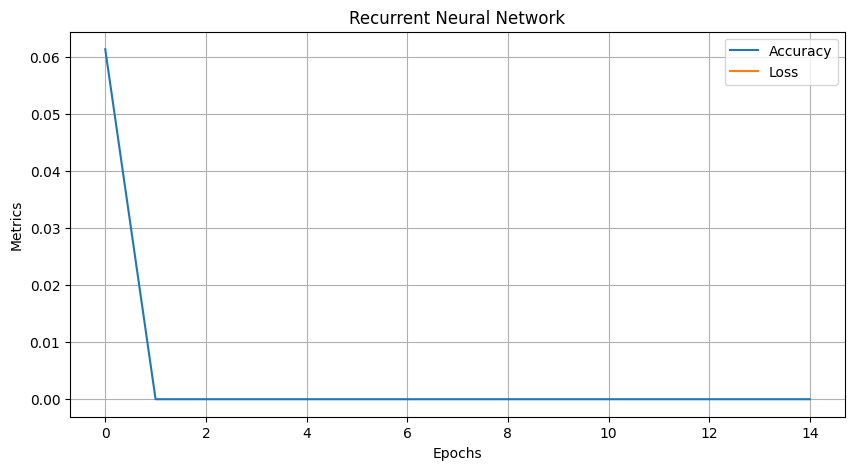

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Recurrent Neural Network Accuracy: 0.56
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       756
           1       0.00      0.00      0.00       585

    accuracy                           0.56      1341
   macro avg       0.28      0.50      0.36      1341
weighted avg       0.32      0.56      0.41      1341



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


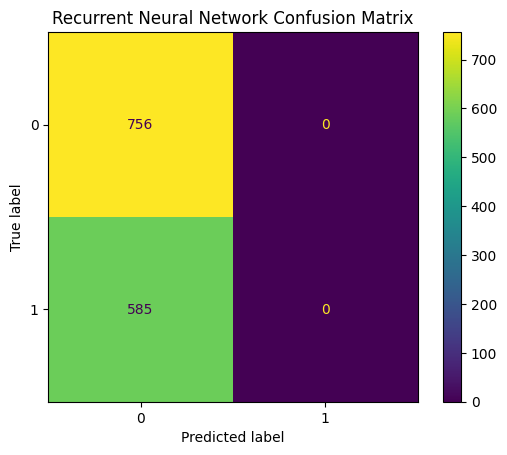

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# ---------------------------------------
# Recurrent Neural Network
# ---------------------------------------
# Reshape data for RNN
X_train_rnn = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_test_rnn = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)

# Build the Recurrent Neural Network
rnn_model = Sequential([
    Input(shape=(X_train_rnn.shape[1], 1)),
    SimpleRNN(64, activation='relu', return_sequences=True),
    Dropout(0.3),
    SimpleRNN(32, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train_encoded.shape[1], activation='softmax')
])

# Use a smaller learning rate
optimizer = Adam(learning_rate=0.001)

# Compile the model
rnn_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_rnn = rnn_model.fit(X_train_rnn, y_train_encoded, epochs=15, batch_size=32, verbose=1)

# Function to Plot Training History
def plot_training_history(history, title):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.plot(history.history['loss'], label='Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid()
    plt.show()

# Plot training history
plot_training_history(history_rnn, 'Recurrent Neural Network')

# Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='viridis')
    plt.title(title)
    plt.show()

# Function to Evaluate Model
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test.argmax(axis=1), y_pred.argmax(axis=1))
    print(f"{title} Accuracy: {accuracy:.2f}")
    print(classification_report(y_test.argmax(axis=1), y_pred.argmax(axis=1)))
    plot_confusion_matrix(y_test, y_pred, f"{title} Confusion Matrix")
    return accuracy

# Evaluate the model
rnn_accuracy = evaluate_model(rnn_model, X_test_rnn, y_test_encoded, 'Recurrent Neural Network')
